In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

In [2]:
df = pd.read_csv(r"developer_burnout_dataset_7000.csv")
df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (7000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,6860.0,32.129446,7.230254,20.00,26.0000,32.000,38.0000,44.00
experience_years,6860.0,9.581050,5.760972,0.00,5.0000,10.000,15.0000,19.00
daily_work_hours,6860.0,9.000277,2.863944,4.00,6.5600,8.990,11.4225,14.00
sleep_hours,6860.0,6.485638,1.445008,4.00,5.2200,6.460,7.7400,9.00
caffeine_intake,6860.0,3.540671,2.283445,0.00,2.0000,4.000,6.0000,7.00
bugs_per_day,6860.0,9.482653,5.751664,0.00,5.0000,9.000,14.0000,19.00
commits_per_day,6860.0,14.458455,8.669846,0.00,7.0000,14.000,22.0000,29.00
meetings_per_day,6860.0,4.545044,2.856766,0.00,2.0000,5.000,7.0000,9.00
screen_time,6860.0,11.974773,3.091204,5.21,9.4600,12.020,14.4225,18.93
exercise_hours,6860.0,1.007611,0.576708,0.00,0.5100,1.020,1.5100,2.00


In [5]:
df.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [6]:
df = df.dropna()
df.isnull().sum()

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64

In [22]:
df = df[df["burnout_level"].notna()].copy()

df["burnout_level"] = df["burnout_level"].map({
    "High": 1,
    "Medium": 0,
    "Low": 0
})

df["burnout_level"].value_counts()

Series([], Name: count, dtype: int64)

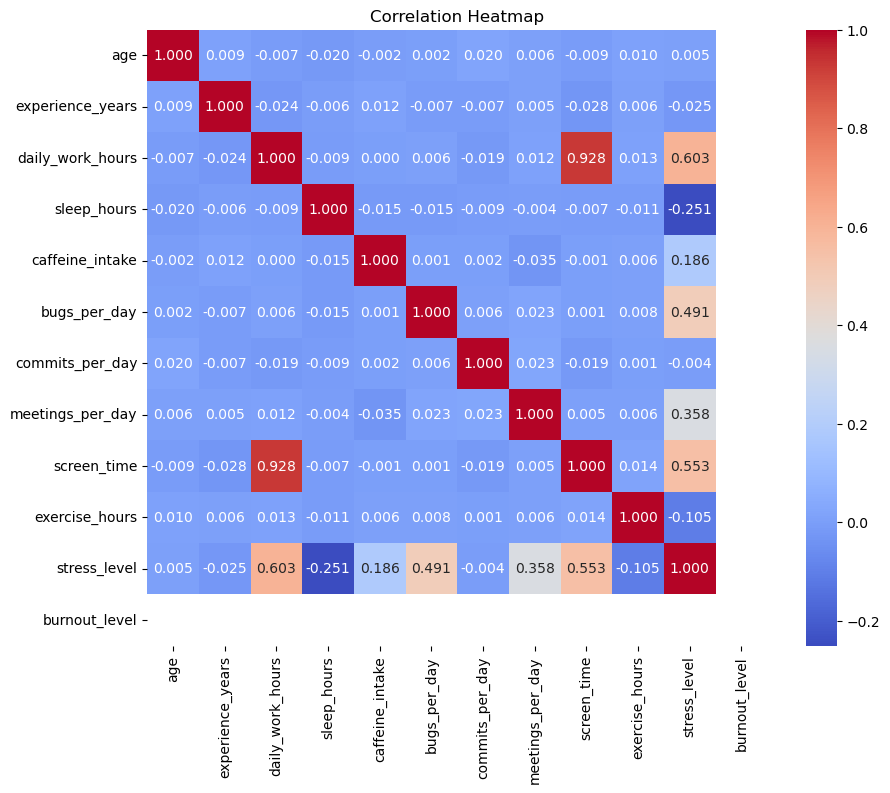

In [23]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap")
plt.show()

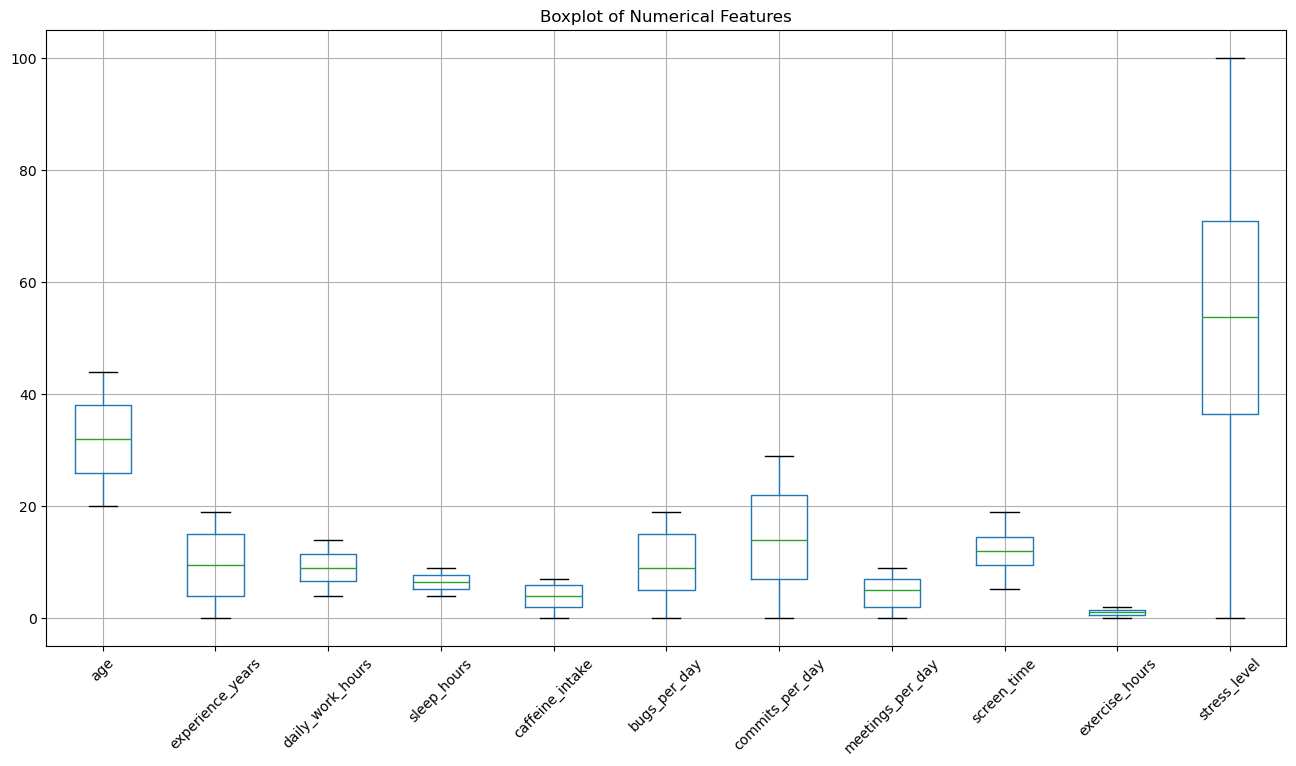

In [24]:
numeric_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != "burnout_level"]

plt.figure(figsize=(16, 8))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [25]:
df_final = df.drop(columns=["stress_level", "commits_per_day", "screen_time"])

In [27]:
print(df_final.head())

    age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  26.0              12.0             10.33         4.45              2.0   
1  39.0              10.0              8.62         5.77              5.0   
3  30.0               1.0              6.85         6.47              2.0   
5  40.0               2.0             10.25         6.78              0.0   
7  38.0               0.0             10.69         5.25              5.0   

   bugs_per_day  meetings_per_day  exercise_hours  burnout_level  
0          11.0               1.0            0.14            NaN  
1          15.0               5.0            0.54            NaN  
3          15.0               1.0            0.96            NaN  
5          19.0               4.0            0.78            NaN  
7          12.0               2.0            0.10            NaN  


In [13]:
X = df_final.drop(columns=["burnout_level"])
y = df_final["burnout_level"]

print(X.shape)
print(y.shape)

(5490, 8)
(5490,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3678, 8)
X_test shape: (1812, 8)


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred_log = log_model.predict(X_test_scaled)
y_score_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [21]:
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC :", roc_auc_score(y_test, y_score_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].